# Crude Monte Carlo and Randomized Quasi Monte Carlo Comparison

In [4]:
#init
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time




# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
N = 2**13            # Number of paths (power of 2 for QMC)
batches = 32          # Number of batches/scrambles 32

out_dir = 'Graphs'
dir_Tables = 'Tables'
os.makedirs(out_dir, exist_ok=True)
os.makedirs(dir_Tables, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data Generation

In [5]:
test_cases= range(8,19)# 256 .. 524.288 insert 20
N_values = [2**k for k in test_cases]  
N_values_labels = [f"${2}^{{{k}}}$" for k in  test_cases]
prices_mc, errors_mc, cis_mc, times_mc = sim.plot_convergence(N_values,method='mc', batches=batches)
prices_qmc, errors_qmc, cis_qmc, times_qmc = sim.plot_convergence(N_values,method='qmc + bb', batches=batches)

# Format CI data
def fmt_ci(ci):
    for i in range(len(ci)):
        low, high = ci[i]
        ci[i] = (float(low), float(high))
    return ci

cis_mc = fmt_ci(cis_mc)
cis_qmc = fmt_ci(cis_qmc)

# Handle CI input for matplotlib errorbar
def ci_to_yerr(prices, cis):
    """Convert CI information to yerr accepted by plt.errorbar."""
    prices = np.asarray(prices, dtype=float)
    cis_arr = np.asarray(cis)
    if cis_arr.ndim == 2 and cis_arr.shape[1] == 2:
        lows = cis_arr[:, 0].astype(float)
        highs = cis_arr[:, 1].astype(float)
        lower_err = prices - lows
        upper_err = highs - prices
    return np.vstack([lower_err, upper_err])
# Build yerr arrays robustly
yerr_mc = ci_to_yerr(np.array(prices_mc), cis_mc)
yerr_qmc = ci_to_yerr(np.array(prices_qmc), cis_qmc)


## Estimated Price v Paths

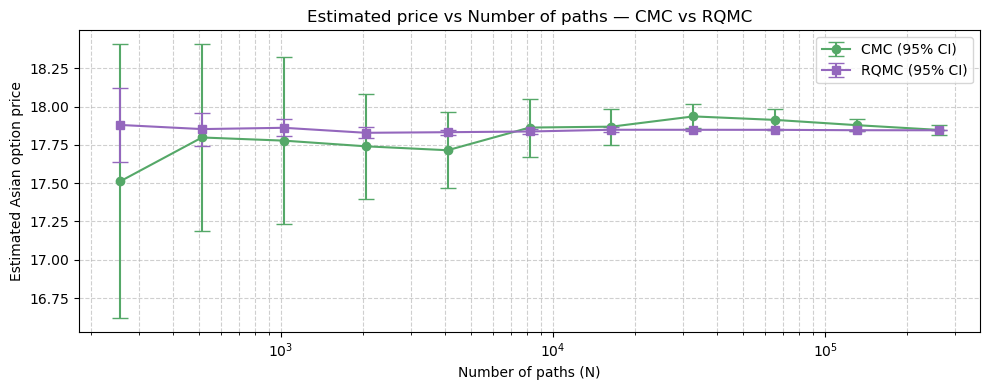

In [6]:
# Plot results
plt.figure(figsize=(10,4))
plt.errorbar(N_values, prices_mc, yerr=yerr_mc, label=f'CMC (95% CI)', marker='o', capsize=6, color='#55A868')
plt.errorbar(N_values, prices_qmc, yerr=yerr_qmc, label=f'RQMC (95% CI)', marker='s', capsize=6, color='#9467bd')
plt.xscale('log', base=10)
plt.xlabel('Number of paths (N)')
plt.ylabel('Estimated Asian option price')
plt.title('Estimated price vs Number of paths — CMC vs RQMC')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'CMC_vs_RQMC_convergence.png'), dpi=150)
plt.show()


In [7]:
N_values

[256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144]

## Std. error v Paths

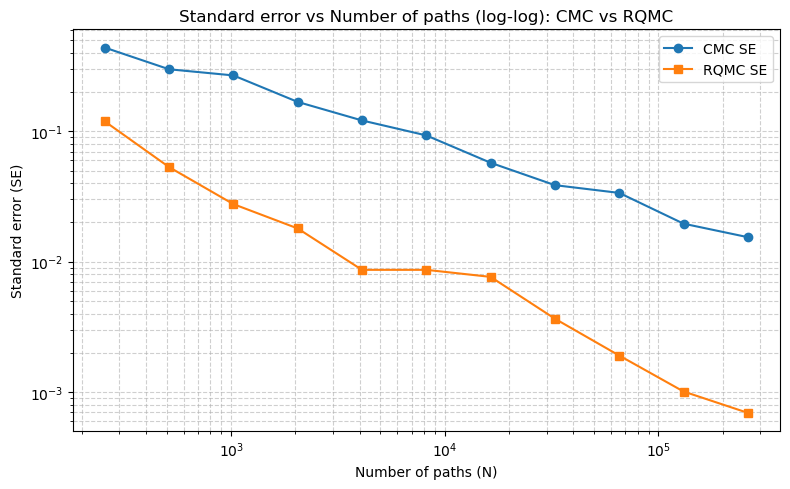

<Figure size 640x480 with 0 Axes>

In [8]:
# Standard error vs Number of paths (log-log)

plt.figure(figsize=(8,5))
plt.loglog(N_values, errors_mc, marker='o', label='CMC SE')
plt.loglog(N_values, errors_qmc, marker='s', label='RQMC SE')

plt.xlabel('Number of paths (N)')
plt.ylabel('Standard error (SE)')
plt.title('Standard error vs Number of paths (log-log): CMC vs RQMC')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.tight_layout()
plt.show()
# Save figure
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, 'SE_vs_N_loglog.png'), dpi=150)

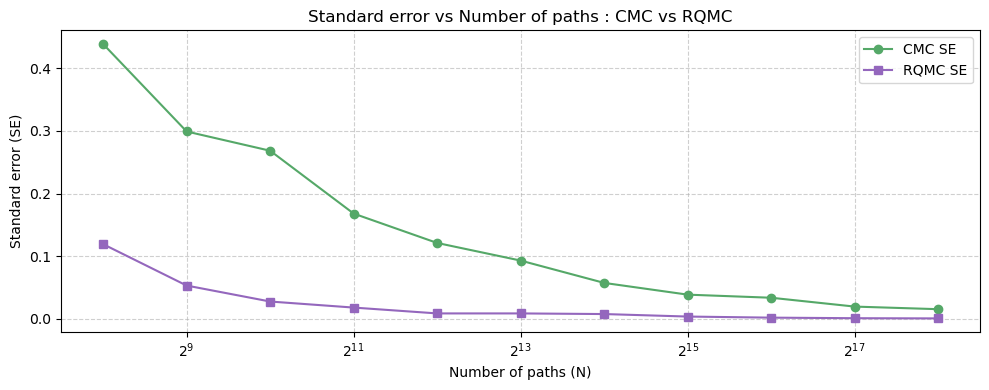

In [9]:
# Standard error vs Number of paths (log-log)

plt.figure(figsize=(10,4))
plt.plot(N_values, errors_mc, marker='o', label='CMC SE', color='#55A868')
plt.plot(N_values, errors_qmc, marker='s', label='RQMC SE', color='#9467bd')

plt.xlabel('Number of paths (N)')
plt.ylabel('Standard error (SE)')
plt.title('Standard error vs Number of paths : CMC vs RQMC')
plt.xscale('log', base=2)
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'SE_vs_N_CMC_RQMC.png'), dpi=150)
plt.show()

In [13]:
# Create a dataframe comparing CMC vs RQMC across the tested N_values
# Ensure the 'N' array has the same length as the result arrays to avoid ValueError
N_values_labels = [2**k for k in  test_cases]
expected_len = len(prices_mc)
df_compare = None
# If an existing df_compare already matches the result arrays, reuse it.
# Otherwise, construct a new df_compare using an appropriate N list.
if 'df_compare' in globals() and isinstance(df_compare, pd.DataFrame) and len(df_compare) == expected_len:
    # reuse existing df_compare (assumed to match prices_*/errors_*/times_*)
    pass
else:
    # Determine N_list that matches the length of the result arrays.
    if 'N_values' in globals() and len(N_values) == expected_len:
        N_list = N_values
    else:
        # Fallback: reconstruct a powers-of-two sequence starting at 2**8
        N_list = [2**k for k in range(8, 8 + expected_len)]

    df_compare = pd.DataFrame({
        'N': N_values_labels,
        'Price$_{mc}$': np.array(prices_mc),
        'SE$_{mc}$': np.array(errors_mc),
        'Time$_{mc}$': np.array(times_mc),
        'Price$_{qmc}$': np.array(prices_qmc),
        'SE$_{qmc}$': np.array(errors_qmc),
        'Time$_{qmc}$': np.array(times_qmc),
    })

    # Useful metrics
    #df_compare['se_ratio_mc_to_qmc'] = df_compare['se$_{mc}$'] / df_compare['se$_{qmc}$']  # how many times SE_mc is bigger than SE_qmc
    df_compare['VRF'] = ((df_compare['SE$_{mc}$']**2)/ (df_compare['SE$_{qmc}$']**2)) 
    df_compare['Time ratio'] = df_compare['Time$_{qmc}$'] / df_compare['Time$_{mc}$']  # how many times time_mc is bigger than time_qmc

# Display and save for later reference
df_compare.drop(columns=['se_ratio_mc_to_qmc'], errors='ignore', inplace=True)
df_display=df_compare[['N', 'Price$_{mc}$', 'SE$_{mc}$', 'Time$_{mc}$', 'Price$_{qmc}$', 'SE$_{qmc}$', 'Time$_{qmc}$', 'VRF']]

latex_path = os.path.join(dir_Tables, 'CMC_vs_RQMC_comparison.tex')
df_display.to_latex(buf=latex_path, index=False, float_format="%.4f")
df_display


,N,Price$_{mc}$,SE$_{mc}$,Time$_{mc}$,Price$_{qmc}$,SE$_{qmc}$,Time$_{qmc}$,VRF
0,256,17.511980,0.438828,0.681258,17.880562,0.119211,1.216039,13.550534
1,512,17.798676,0.299177,0.778357,17.853475,0.053135,1.336767,31.703079
2,1024,17.778046,0.268424,0.994819,17.861946,0.027637,1.705138,94.335683
3,2048,17.741042,0.168071,1.444884,17.829255,0.017978,2.218020,87.397418
4,4096,17.715375,0.121160,2.225786,17.833175,0.008651,3.573527,196.135571
5,8192,17.863491,0.093012,3.970450,17.837770,0.008653,6.202305,115.553246
6,16384,17.869376,0.057364,7.244436,17.849087,0.007641,11.706431,56.362080
7,32768,17.936329,0.038625,14.682499,17.848893,0.003648,23.522096,112.080512
8,65536,17.913426,0.033685,32.536878,17.848634,0.001904,55.295046,313.155854
9,131072,17.879001,0.019559,83.948137,17.846096,0.001009,183.192703,376.059815


In [ ]:
# Select only the N values you want to keep
Ns_to_keep = ['2^{18}', '2^{18}', '2^{18}', '2^{18}', '2^{18}']  # modify this list as needed

# Filter df_compare and reset index for display
df_subset = df_compare[df_compare['N'].isin(Ns_to_keep)].reset_index(drop=True)

# (Optional) update N_values variable if later cells should use the reduced set
N_values = df_subset['N'].tolist()
df_subset
# Show the subset
latex_path = os.path.join(dir_Tables, 'CMC_vs_RQMC_comparison.tex')
df_subset.to_latex(buf=latex_path, index=False, float_format="%.4f")